In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Call Library

In [ ]:
# Basic Libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

#Load dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Training_Labels.csv")
image_paths = "/content/drive/MyDrive/Dataset/Training_Set/Training/" + df["ID"].astype(str) + ".png"

val_df= pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Validation_Labels.csv")
val_paths = "/content/drive/MyDrive/Dataset/Validation/" + val_df["ID"].astype(str) + ".png"

test_df = pd.read_csv("/content/drive/MyDrive/Dataset1/RFMiD_Testing_Labels.csv")
test_paths = "/content/drive/MyDrive/Dataset1/Test/" + test_df["ID"].astype(str) + ".png"

labels = df["Disease_Risk"].to_numpy()
val_labels = val_df["Disease_Risk"].to_numpy()
test_labels = test_df["Disease_Risk"].to_numpy()

data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image/255.0
    return image, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
drive_path = '/content/drive/MyDrive'
print(f"Listing contents of: {drive_path}")

for root, dirs, files in os.walk(drive_path):
    level = root.replace(drive_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')

In [ ]:
print("Train:\n", df["Disease_Risk"].value_counts())
print("Val:\n", val_df["Disease_Risk"].value_counts())
print("Test:\n", test_df["Disease_Risk"].value_counts())

Train:
 Disease_Risk
1    1519
0     401
Name: count, dtype: int64
Val:
 Disease_Risk
1    506
0    134
Name: count, dtype: int64
Test:
 Disease_Risk
1    506
0    134
Name: count, dtype: int64


#Visualization

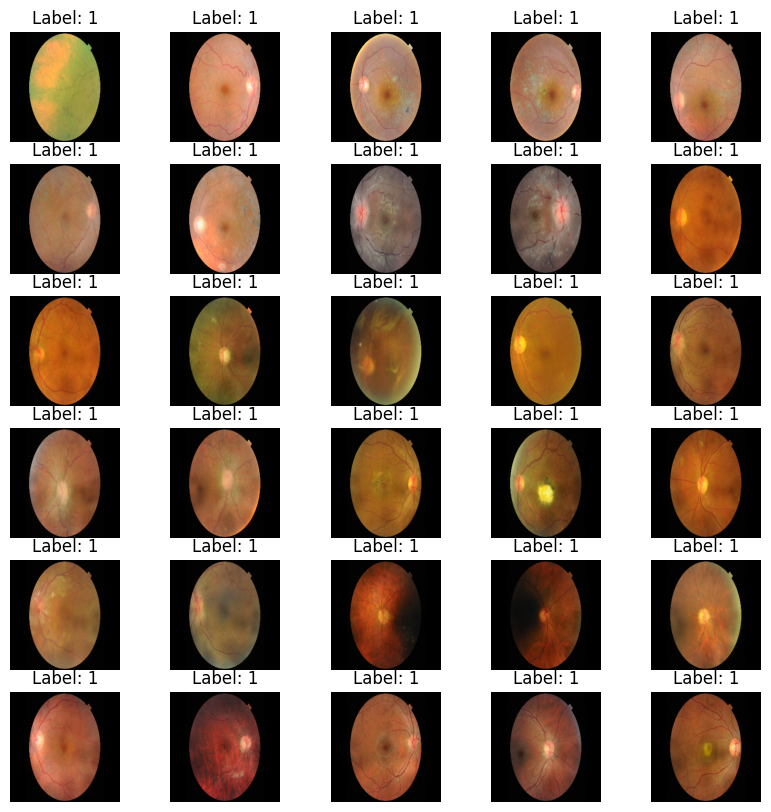

In [ ]:
img, label = next(iter(val))

plt.figure(figsize=(10,10))

for i in range(30):
    # Adjusted subplot to 5 rows and 4 columns to accommodate 20 images
    plt.subplot(6, 5, i + 1)
    plt.imshow((img[i].numpy()*255).astype("uint8"))
    plt.title(f"Label: {label[i].numpy()}") # Removed [0] as label[i].numpy() is already a scalar
    plt.axis("off")

plt.show()

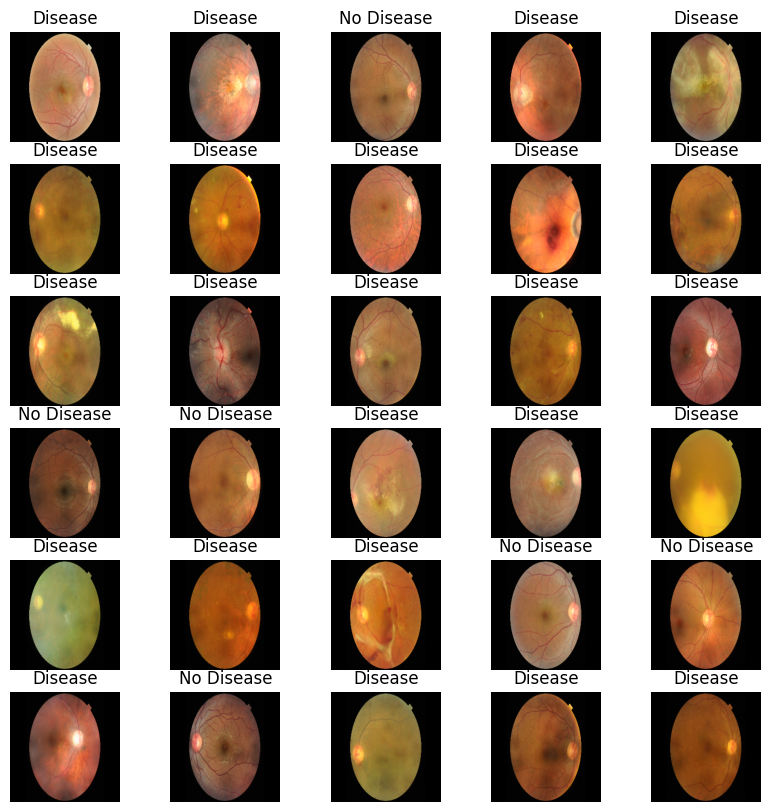

In [ ]:
images, labels = next(iter(data))

plt.figure(figsize=(10,10))

for i in range(30):
    plt.subplot(6, 5, i + 1)
    plt.imshow((images[i].numpy()*255).astype("uint8"))

    label = labels[i].numpy()
    text = "No Disease" if label == 0 else "Disease"

    plt.title(text)
    plt.axis("off")
plt.show()

#Load ResNet50

In [ ]:
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Unfreeze last few layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Custom classifier
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    x = layers.Dropout(0.5)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    # Final model
    model = models.Model(inputs=base_model.input, outputs=output)
    return model


# Instantiate model
model = build_model()

#Callbacks (Important)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    mode='max')

#Class Imbalance

In [ ]:
# CORRECT — use the full training labels:
labels_np = df["Disease_Risk"].to_numpy()

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_np),
    y=labels_np)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(2.3940149625935163), 1: np.float64(0.6319947333772219)}


#Compile

In [ ]:
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss

loss= focal_loss()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()])
history = model.fit(data,validation_data=val,epochs=15,class_weight=class_weights,callbacks=[early_stop])

#model.summary()

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 947s 15s/step - accuracy: 0.7875 - loss: 0.0557 - precision: 0.7910 - recall: 0.9941 - val_accuracy: 0.7906 - val_loss: 0.0666 - val_precision: 0.7906 - val_recall: 1.0000
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.7922 - loss: 0.0494 - precision: 0.7920 - recall: 1.0000 - val_accuracy: 0.7906 - val_loss: 0.0633 - val_precision: 0.7906 - val_recall: 1.0000
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.7911 - loss: 0.0469 - precision: 0.7939 - recall: 0.9941 - val_accuracy: 0.7906 - val_loss: 0.1003 - val_precision: 0.7906 - val_recall: 1.0000
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.7969 - loss: 0.0443 - precision: 0.7963 - recall: 0.9987 - val_accuracy: 0.8438 - val_loss: 0.0767 - val_precision: 0.8625 - val_recall: 0.9545
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.7917 - loss: 0.0452 - precision: 0.7925 - recall: 0.9980 - val_accuracy: 0.7922 - val_loss: 0.0727

#Accuracy and Loss Evaluation

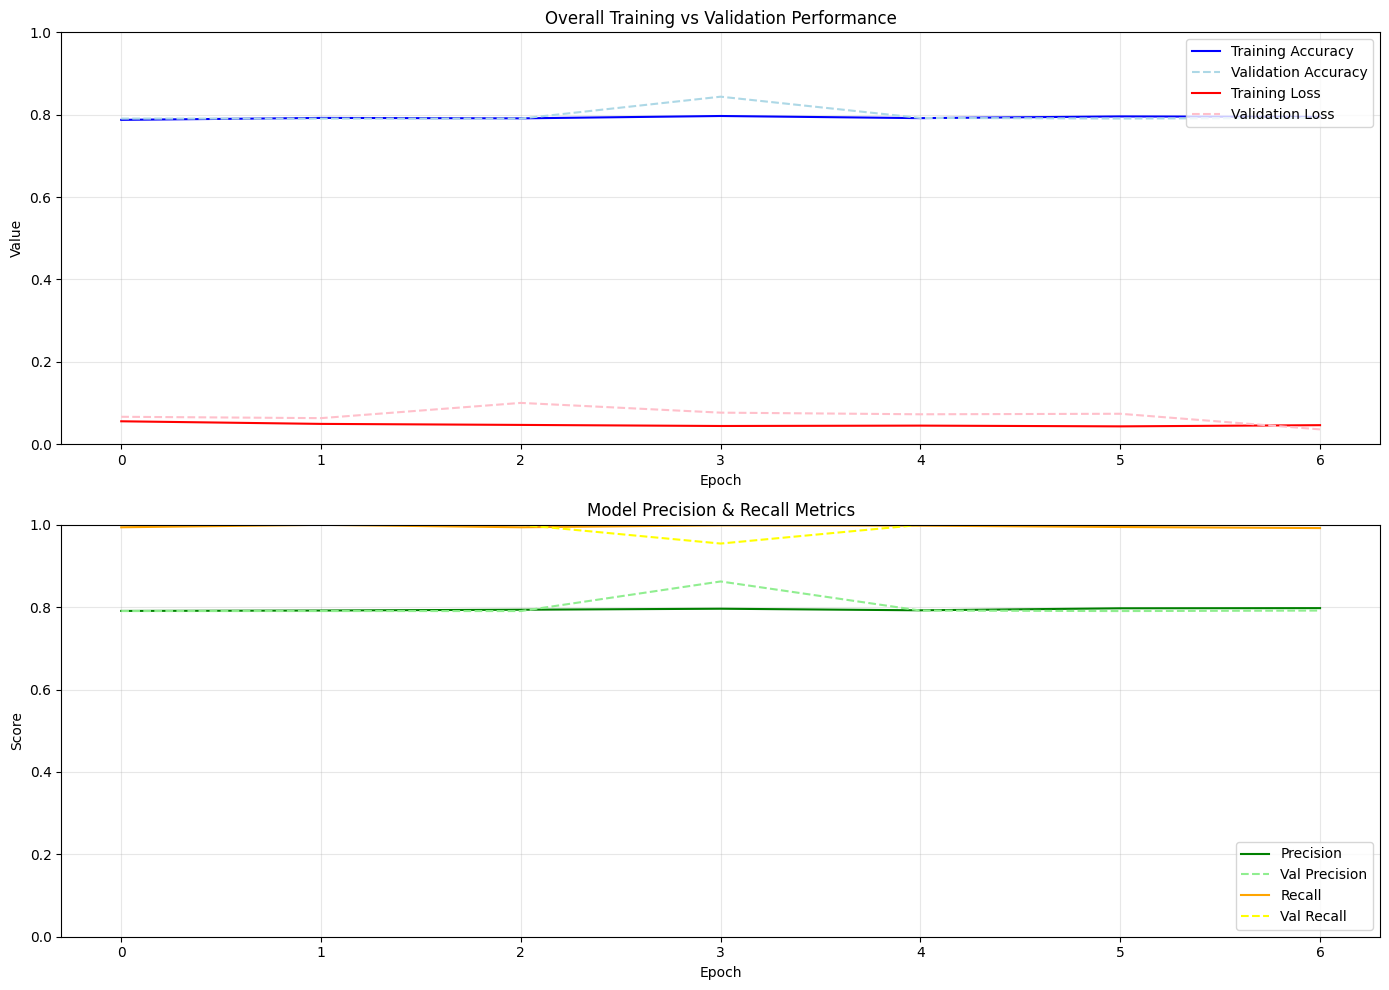

In [ ]:
# Create a figure with two rows of plots
plt.figure(figsize=(14, 10))

# 1. Accuracy and Loss (Your original requested plot)
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='lightblue', linestyle='--')
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='pink', linestyle='--')
plt.title("Overall Training vs Validation Performance")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 1])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 2. Precision and Recall (The new requested plot)
plt.subplot(2, 1, 2)
plt.plot(history.history['precision'], label='Precision', color='green')
plt.plot(history.history['val_precision'], label='Val Precision', color='lightgreen', linestyle='--')
plt.plot(history.history['recall'], label='Recall', color='orange')
plt.plot(history.history['val_recall'], label='Val Recall', color='yellow', linestyle='--')
plt.title("Model Precision & Recall Metrics")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Evaluate

In [ ]:
test_loss, test_acc, test_recall, test_precision = model.evaluate(test)

print("Test Accuracy:", test_acc)
print("Test Recall:", test_recall)
print("Test Precision:", test_precision)

20/20 ━━━━━━━━━━━━━━━━━━━━ 350s 18s/step - accuracy: 0.7906 - loss: 0.1005 - precision: 0.7906 - recall: 1.0000
Test Accuracy: 0.7906249761581421
Test Recall: 1.0
Test Precision: 0.7906249761581421


#Predictions

In [ ]:
y_pred = model.predict(test)

# Convert probabilities → 0/1
y_pred = (y_pred > 0.3).astype(int).flatten()
y_true = test_labels

20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step


# Confusion Matrix

In [ ]:
y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

In [ ]:
# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#  Classification

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       134
           1       0.79      1.00      0.88       506

    accuracy                           0.79       640
   macro avg       0.40      0.50      0.44       640
weighted avg       0.63      0.79      0.70       640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Calculation

In [ ]:
# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# etrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")

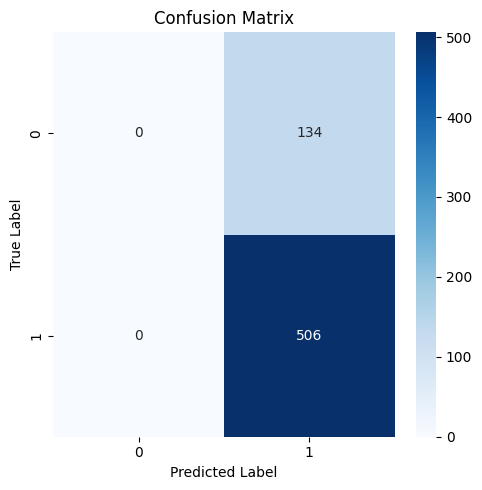

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


cm = np.array([[0, 134],
              [0, 506]])


plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig('confusion_matrix.png')

#Calculation

In [ ]:
import numpy as np

# Given confusion matrix

cm = np.array([[0, 134],
              [0, 506]])

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")


Model Performance:

Accuracy     : 0.7906
Precision    : 0.7906
Recall       : 1.0000
Specificity  : 0.0000
F1 Score     : 0.8831
